In [1]:
!pip install pandas numpy matplotlib seaborn scipy scikit-learn statsmodels

  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached statsmodels-0.14.6-cp314-cp314-win_amd64.whl.metadata (9.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached statsmodels-0.14.6-cp314-cp314-win_amd64.whl (9.6 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)

   ---------------------------------------- 0/4 [patsy]
   ---------------------------------------- 0/4 [patsy]
   ---------------------------------------- 0/4 [patsy]
   ---------------------------------------- 0/4 [patsy]
   ---------------------------------------- 0/4 [patsy]
   ---------------------------------------- 0/4 [patsy]
   ---------------------------------------- 0/4 [patsy]
   ---------- ----------------------------- 1/4 [joblib]
   ---------- -----------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import statsmodels.api as sm

In [3]:
df = pd.read_csv("../data/SampleSuperStore.csv")

df.head()

,Order ID,Customer Name,Category,Sales,Quantity,Profit,Region,Order Date
0,O001,Rahul,Furniture,5000,2,800,South,2024-01-05
1,O002,Priya,Technology,12000,1,2500,East,2024-01-08
2,O003,Arjun,Office Supplies,800,4,120,West,2024-01-10
3,O004,Sneha,Furniture,3000,3,450,North,2024-01-12
4,O005,Ravi,Technology,9500,2,1800,South,2024-01-15


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5
Number of columns: 8


In [5]:
print(df.columns.tolist())

['Order ID', 'Customer Name', 'Category', 'Sales', 'Quantity', 'Profit', 'Region', 'Order Date']


In [6]:
sales = df["Sales"].dropna()

print("Total Sales:", sales.sum())
print("Mean Sales:", sales.mean())
print("Median Sales:", sales.median())
print("Mode Sales:", sales.mode()[0])
print("Standard Deviation:", sales.std())
print("Skewness:", sales.skew())

Total Sales: 30300
Mean Sales: 6060.0
Median Sales: 5000.0
Mode Sales: 800
Standard Deviation: 4617.141973125799
Skewness: 0.3171386824775819


In [7]:
df[["Sales", "Quantity", "Profit"]].describe()

,Sales,Quantity,Profit
count,5.000000,5.000000,5.000000
mean,6060.000000,2.400000,1134.000000
std,4617.141973,1.140175,989.585772
min,800.000000,1.000000,120.000000
25%,3000.000000,2.000000,450.000000
50%,5000.000000,2.000000,800.000000
75%,9500.000000,3.000000,1800.000000
max,12000.000000,4.000000,2500.000000


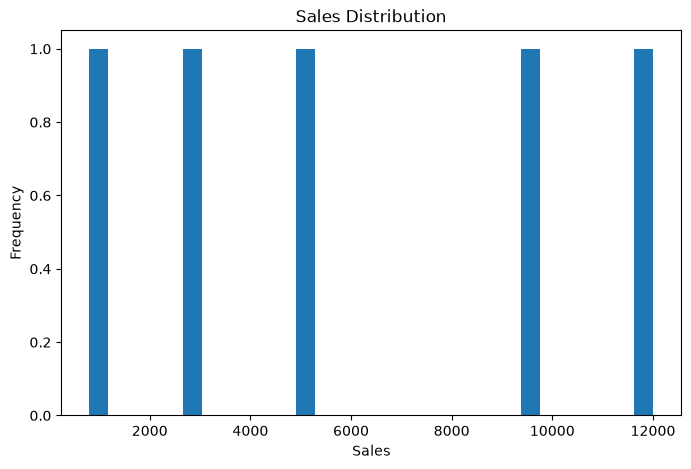

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(df["Sales"].dropna(), bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

In [9]:
sales = df["Sales"].dropna()

print("Total Sales:", sales.sum())
print("Mean Sales:", sales.mean())
print("Median Sales:", sales.median())
print("Mode Sales:", sales.mode()[0])
print("Standard Deviation:", sales.std())
print("Skewness:", sales.skew())

Total Sales: 30300
Mean Sales: 6060.0
Median Sales: 5000.0
Mode Sales: 800
Standard Deviation: 4617.141973125799
Skewness: 0.3171386824775819


In [10]:
df[["Sales", "Quantity", "Profit"]].describe()

,Sales,Quantity,Profit
count,5.000000,5.000000,5.000000
mean,6060.000000,2.400000,1134.000000
std,4617.141973,1.140175,989.585772
min,800.000000,1.000000,120.000000
25%,3000.000000,2.000000,450.000000
50%,5000.000000,2.000000,800.000000
75%,9500.000000,3.000000,1800.000000
max,12000.000000,4.000000,2500.000000


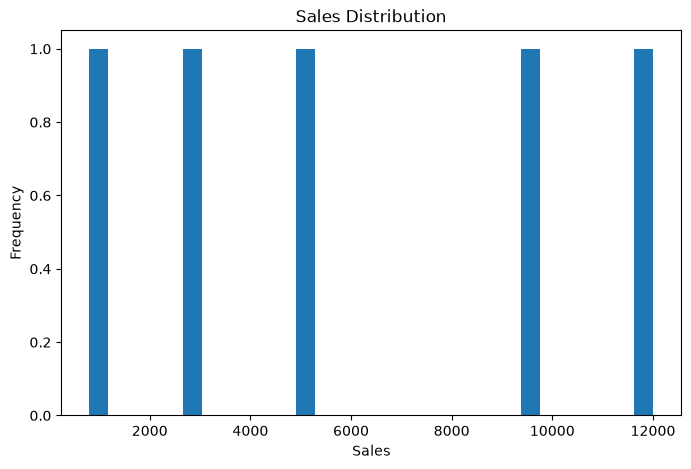

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(df["Sales"].dropna(), bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

In [12]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nSales values:")
print(df["Sales"].tolist())

Number of rows: 5
Number of columns: 8

Sales values:
[5000, 12000, 800, 3000, 9500]


In [13]:
df.head(10)

,Order ID,Customer Name,Category,Sales,Quantity,Profit,Region,Order Date
0,O001,Rahul,Furniture,5000,2,800,South,2024-01-05
1,O002,Priya,Technology,12000,1,2500,East,2024-01-08
2,O003,Arjun,Office Supplies,800,4,120,West,2024-01-10
3,O004,Sneha,Furniture,3000,3,450,North,2024-01-12
4,O005,Ravi,Technology,9500,2,1800,South,2024-01-15


In [14]:
sales = df["Sales"].dropna()

print("Total Sales:", sales.sum())
print("Mean Sales:", sales.mean())
print("Median Sales:", sales.median())
print("Mode Sales:", sales.mode().tolist())
print("Standard Deviation:", sales.std())
print("Skewness:", sales.skew())

Total Sales: 30300
Mean Sales: 6060.0
Median Sales: 5000.0
Mode Sales: [800, 3000, 5000, 9500, 12000]
Standard Deviation: 4617.141973125799
Skewness: 0.3171386824775819


In [15]:
sales = df["Sales"].dropna()

mean_sales = sales.mean()
standard_error = stats.sem(sales)

confidence_interval = stats.t.interval(
    0.95,
    len(sales) - 1,
    loc=mean_sales,
    scale=standard_error
)

print("Mean Sales:", mean_sales)
print("95% Confidence Interval:", confidence_interval)

Mean Sales: 6060.0
95% Confidence Interval: (np.float64(327.0610373742038), np.float64(11792.938962625796))


### Confidence Interval Interpretation

The average sales value is 6060. The 95% confidence interval ranges approximately from 327.06 to 11792.94. The wide interval is mainly due to the very small sample size of five records.

In [16]:
south_sales = df[df["Region"] == "South"]["Sales"]
east_sales = df[df["Region"] == "East"]["Sales"]

print("South Sales:", south_sales.tolist())
print("East Sales:", east_sales.tolist())

South Sales: [5000, 9500]
East Sales: [12000]


In [17]:
t_stat, p_value = stats.ttest_ind(
    south_sales,
    east_sales,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: nan
P-value: nan


### T-Test Interpretation

An independent t-test was attempted to compare sales between the South and East regions. However, the dataset contains only two observations for South and one observation for East. Therefore, the resulting p-value is not statistically reliable. A larger dataset would be required to draw a meaningful conclusion about differences in regional sales.

In [18]:
contingency_table = pd.crosstab(
    df["Category"],
    df["Region"]
)

print(contingency_table)

Region           East  North  South  West
Category                                 
Furniture           0      1      1     0
Office Supplies     0      0      0     1
Technology          1      0      1     0


In [19]:
chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 7.500000000000001
P-value: 0.27706844336610725
Degrees of freedom: 6


### Chi-Square Test Interpretation

A chi-square test was performed to examine the relationship between product category and region. Due to the very small sample size and low expected frequencies, the result should not be considered statistically reliable. A larger dataset would be needed to establish a meaningful relationship between category and region.

In [20]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

print(df["Order Date"].dtype)

datetime64[us]


In [21]:
df_time = df.set_index("Order Date").copy()

df_time.head()

,Order ID,Customer Name,Category,Sales,Quantity,Profit,Region
Order Date,,,,,,,
2024-01-05,O001,Rahul,Furniture,5000,2,800,South
2024-01-08,O002,Priya,Technology,12000,1,2500,East
2024-01-10,O003,Arjun,Office Supplies,800,4,120,West
2024-01-12,O004,Sneha,Furniture,3000,3,450,North
2024-01-15,O005,Ravi,Technology,9500,2,1800,South


In [22]:
monthly_sales = df_time["Sales"].resample("ME").sum()

print(monthly_sales)

Order Date
2024-01-31    30300
Freq: ME, Name: Sales, dtype: int64


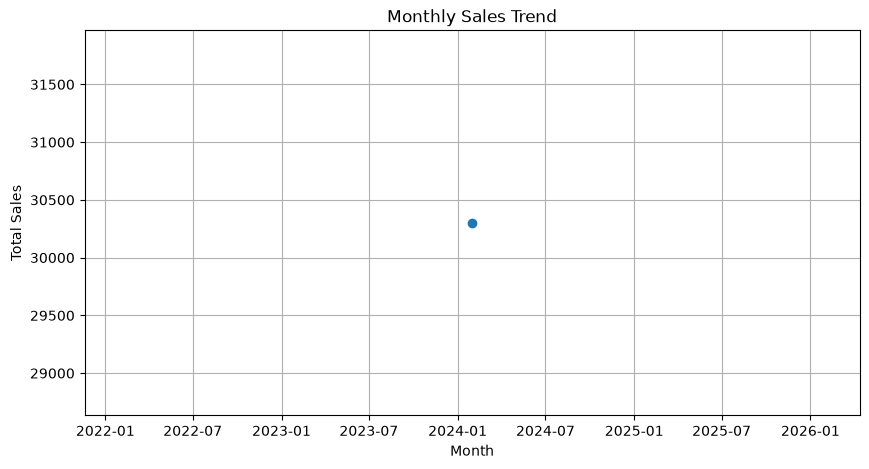

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)
plt.show()

In [24]:
daily_sales = df_time["Sales"].resample("D").sum()

print(daily_sales[daily_sales > 0])

Order Date
2024-01-05     5000
2024-01-08    12000
2024-01-10      800
2024-01-12     3000
2024-01-15     9500
Name: Sales, dtype: int64


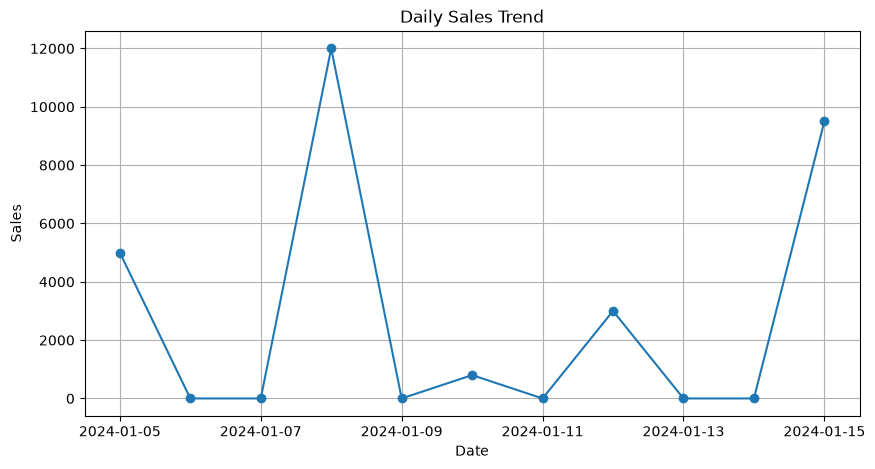

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(
    daily_sales.index,
    daily_sales.values,
    marker="o"
)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)
plt.show()

In [26]:
moving_average = daily_sales.rolling(window=3).mean()

print(moving_average[moving_average.notna()])

Order Date
2024-01-07    1666.666667
2024-01-08    4000.000000
2024-01-09    4000.000000
2024-01-10    4266.666667
2024-01-11     266.666667
2024-01-12    1266.666667
2024-01-13    1000.000000
2024-01-14    1000.000000
2024-01-15    3166.666667
Freq: D, Name: Sales, dtype: float64


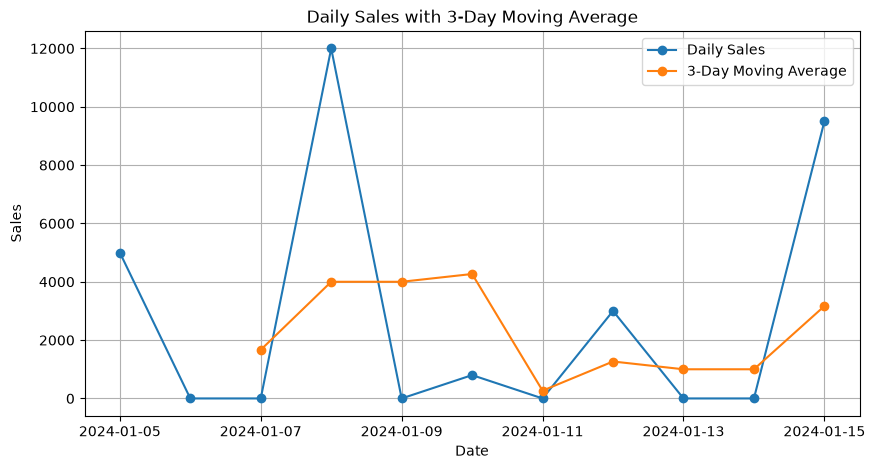

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    daily_sales.index,
    daily_sales.values,
    marker="o",
    label="Daily Sales"
)

plt.plot(
    moving_average.index,
    moving_average.values,
    marker="o",
    label="3-Day Moving Average"
)

plt.title("Daily Sales with 3-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

### Time Series Analysis Interpretation

The sales data was converted into a time series and resampled at daily and monthly levels. The daily sales trend shows variation across the five recorded orders, while monthly aggregation gives total sales of 30,300 for January 2024.

A 3-day moving average was calculated to smooth short-term fluctuations. Since the dataset contains only one month of observations, long-term trend and seasonality cannot be reliably identified. A longer historical dataset would be required for meaningful seasonal decomposition and forecasting.

In [28]:
customer_data = df.groupby("Customer Name").agg({
    "Sales": "sum",
    "Quantity": "sum",
    "Profit": "sum"
}).reset_index()

customer_data

,Customer Name,Sales,Quantity,Profit
0,Arjun,800,4,120
1,Priya,12000,1,2500
2,Rahul,5000,2,800
3,Ravi,9500,2,1800
4,Sneha,3000,3,450


In [29]:
features = ["Sales", "Quantity", "Profit"]

X_customer = customer_data[features]

X_customer

,Sales,Quantity,Profit
0,800,4,120
1,12000,1,2500
2,5000,2,800
3,9500,2,1800
4,3000,3,450


In [30]:
scaler = StandardScaler()

scaled_customer_data = scaler.fit_transform(X_customer)

scaled_customer_data

array([[-1.27370109,  1.56892908, -1.14561718],
       [ 1.43836207, -1.37281295,  1.54330678],
       [-0.25667741, -0.39223227, -0.37735319],
       [ 0.83299083, -0.39223227,  0.75244679],
       [-0.7409744 ,  0.58834841, -0.77278319]])

In [31]:
inertia = []

for k in range(2, 5):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(scaled_customer_data)
    inertia.append(kmeans.inertia_)

print("Inertia values:", inertia)

Inertia values: [3.7125724555784685, 1.6529596219037366, 0.6762234600277628]


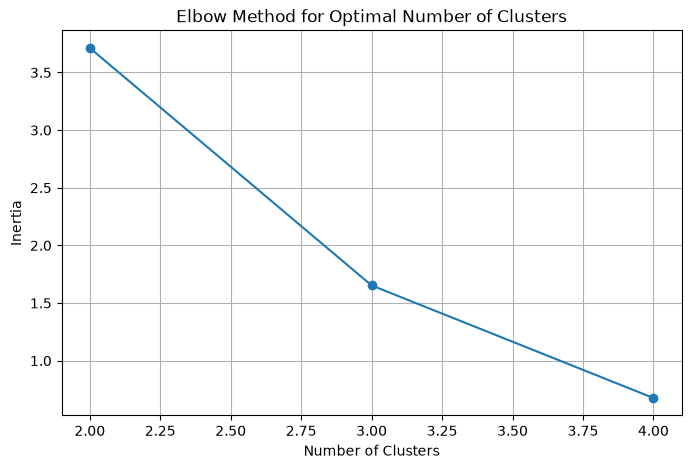

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 5),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.grid(True)
plt.show()

In [33]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

customer_data["Cluster"] = kmeans.fit_predict(
    scaled_customer_data
)

customer_data

,Customer Name,Sales,Quantity,Profit,Cluster
0,Arjun,800,4,120,1
1,Priya,12000,1,2500,0
2,Rahul,5000,2,800,1
3,Ravi,9500,2,1800,0
4,Sneha,3000,3,450,1


In [34]:
cluster_profile = customer_data.groupby("Cluster")[
    ["Sales", "Quantity", "Profit"]
].mean()

cluster_profile

,Sales,Quantity,Profit
Cluster,,,
0,10750.000000,1.5,2150.000000
1,2933.333333,3.0,456.666667


In [35]:
for cluster in sorted(customer_data["Cluster"].unique()):
    print(f"\nCluster {cluster}")
    print(
        customer_data[
            customer_data["Cluster"] == cluster
        ][["Customer Name", "Sales", "Quantity", "Profit"]]
    )


Cluster 0
  Customer Name  Sales  Quantity  Profit
1         Priya  12000         1    2500
3          Ravi   9500         2    1800

Cluster 1
  Customer Name  Sales  Quantity  Profit
0         Arjun    800         4     120
2         Rahul   5000         2     800
4         Sneha   3000         3     450


In [36]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(
    scaled_customer_data
)

customer_data["PCA1"] = pca_data[:, 0]
customer_data["PCA2"] = pca_data[:, 1]

In [37]:
customer_data[
    ["Customer Name", "Cluster", "PCA1", "PCA2"]
]

,Customer Name,Cluster,PCA1,PCA2
0,Arjun,1,-2.298714,0.332378
1,Priya,0,2.514881,0.072177
2,Rahul,1,-0.147154,-0.583364
3,Ravi,0,1.146312,0.302329
4,Sneha,1,-1.215324,-0.123519


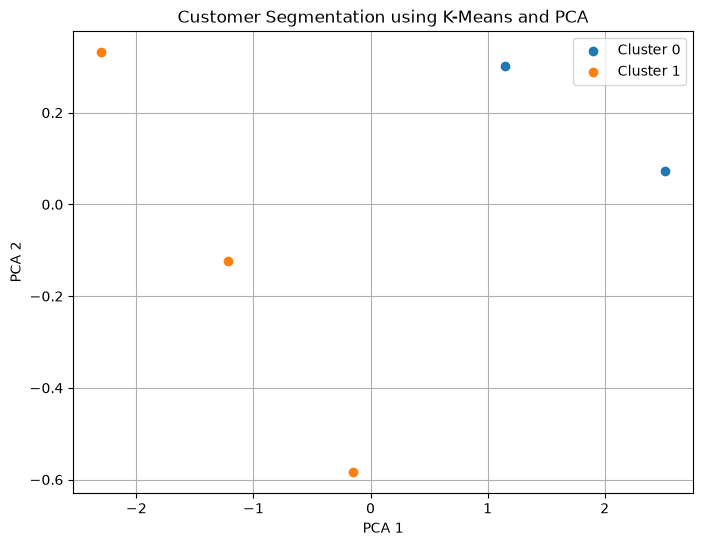

In [38]:
plt.figure(figsize=(8, 6))

for cluster in sorted(customer_data["Cluster"].unique()):
    cluster_points = customer_data[
        customer_data["Cluster"] == cluster
    ]
    
    plt.scatter(
        cluster_points["PCA1"],
        cluster_points["PCA2"],
        label=f"Cluster {cluster}"
    )

plt.title("Customer Segmentation using K-Means and PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)

plt.show()

### Customer Segmentation Interpretation

K-Means clustering was applied to customer-level Sales, Quantity, and Profit after standardizing the features using StandardScaler. Two customer segments were created because the dataset contains only five customers.

The cluster profiles show differences in purchasing value and profitability between the groups. PCA was then used to reduce the three-dimensional feature space to two dimensions for visualization.

Because the dataset contains only five customers, the identified segments should be considered a basic demonstration rather than statistically robust customer segments. A larger customer dataset would provide more reliable segmentation.

In [39]:
model_data = df[["Quantity", "Profit", "Sales"]].dropna()

model_data.head()

,Quantity,Profit,Sales
0,2,800,5000
1,1,2500,12000
2,4,120,800
3,3,450,3000
4,2,1800,9500


In [40]:
X = model_data[["Quantity", "Profit"]]
y = model_data["Sales"]

print("Features:")
print(X)

print("\nTarget:")
print(y)

Features:
   Quantity  Profit
0         2     800
1         1    2500
2         4     120
3         3     450
4         2    1800

Target:
0     5000
1    12000
2      800
3     3000
4     9500
Name: Sales, dtype: int64


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 4
Testing records: 1


In [42]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [43]:
y_pred = model.predict(X_test)

print("Actual Sales:", y_test.values)
print("Predicted Sales:", y_pred)

Actual Sales: [12000]
Predicted Sales: [13201.54615283]


In [44]:
r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", r2)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

R² Score: nan
Mean Absolute Error (MAE): 1201.546152827441
Root Mean Squared Error (RMSE): 1201.546152827441


c:\Users\aswit\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [45]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

feature_importance

,Feature,Coefficient
0,Quantity,-587.455304
1,Profit,4.450073


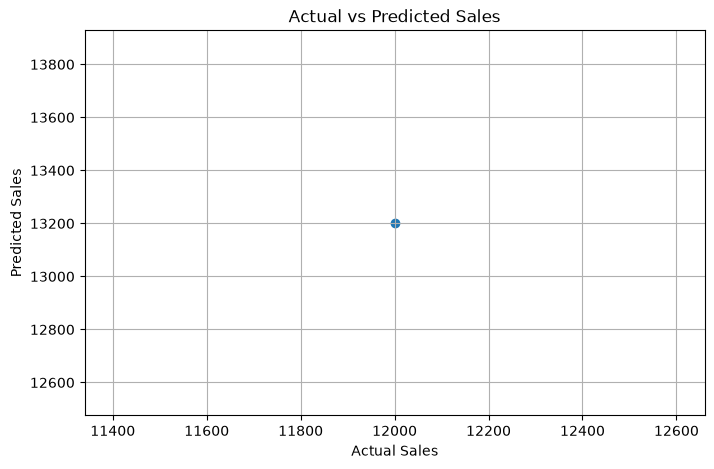

In [46]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.grid(True)
plt.show()

### Predictive Model Interpretation

A Linear Regression model was developed to predict Sales using Quantity and Profit as input features. The dataset was divided into 80% training data and 20% testing data.

The model was evaluated using R², Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE). Because the dataset contains only five observations, the test set contains only one observation, making R² and model performance evaluation statistically unreliable.

The model therefore demonstrates the predictive modeling workflow required for the task, but a larger dataset would be necessary to build and evaluate a reliable sales prediction model.

## Key Findings

1. Total sales in the available dataset were 30,300.
2. The average sales value was 6,060, while the median was 5,000.
3. The sales distribution showed variation between low-value and high-value orders.
4. Customer segmentation identified two basic customer groups using Sales, Quantity, and Profit.
5. Daily sales varied considerably across the recorded January 2024 orders.
6. The 3-day moving average was used to smooth short-term sales fluctuations.
7. Statistical tests and predictive modeling were demonstrated, but the small sample size limits the reliability of statistical conclusions and model evaluation.

## Business Recommendations

1. Focus marketing efforts on customers and segments generating higher sales and profit.
2. Monitor low-performing customer segments and develop targeted offers to increase their purchasing value.
3. Collect a larger historical sales dataset to improve forecasting, customer segmentation, and predictive modeling reliability.